
# Lab 4: FDM-diffusion

 **Exercise** : Heat diffusion in a plate using FDM

Let's consider a rectangular heat-conducting plate with sides of lengths $a=20$ mm and $b=10$ mm. It has borders a temperature as is shown in figure.  The flat faces are isolated, so they can't lose head to the surroundings. The material is aluminum with thermal diffusivity $D\approx 84\, mm^2/s$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/plato_coductor2.jpg" alt="Texto alternativo" width="400" height="400">

1. Use **FDM** to solve the *static solution* for this system for $f(x)=100\,\sin(3\pi x/a)$ C.
2. Compare the *static solution* with the analytical one.
2. Use **FDM** to found the temperature, i.e., solve the diffusion equation for some times.
3. Do a gif for the temperature in time (bonus!)

In [140]:
#Librerias
import matplotlib.pyplot as plt
import numpy as np

In [141]:
def Diffusion2D(V_ini,nx,ny,dt,dx,dy,D):

  u0 = V_ini.copy()
  u = u0.copy()
  dx2, dy2 = dx * dx, dy * dy    

  for i in range(1, ny-1):
      for j in range(1, nx-1):
          uxx = (u0[i+1,j] - 2*u0[i,j] + u0[i-1,j])/dx2
          uyy = (u0[i,j+1] - 2*u0[i,j] + u0[i,j-1])/dy2
          u[i,j] = u0[i,j] + dt*D*(uxx + uyy)
  return u

def Diffusion2D_sli(u0, dt, dx, dy, D):
    u = u0.copy()
    uxx = (u0[1:-1, 2:] - 2 * u0[1:-1, 1:-1] + u0[1:-1, :-2]) / (dx**2)
    uyy = (u0[2:, 1:-1] - 2 * u0[1:-1, 1:-1] + u0[:-2, 1:-1]) / (dy**2)
    u[1:-1, 1:-1] = u0[1:-1, 1:-1] + dt * D * (uxx + uyy)
    return u
  
  
def DifussionStatic(u0, tol):
  t_old = u0.copy()
  t_sta = u0.copy()
  inte = 0
  dif = 1 
  while dif > tol:
    t_sta[1:-1 , 1:-1] =  0.25 * (t_old[2:,1:-1] + t_old[:-2, 1:-1]+t_old[1:-1,2:]+t_old[1:-1,:-2])
    dif = np.max(np.abs(t_sta - t_old))
    t_old = t_sta.copy()
    inte += 1
    
  return t_sta , inte

def Diffusionanalytical(x, y, a, b):
    return 100.0 * (np.sinh(3.0 * np.pi * y / a) / np.sinh(3.0 * np.pi * b / a)) * np.sin(3.0 * np.pi * x / a)

In [142]:
#Tamaño de la placa (mm)
a, b = 20.0, 10.0
#intervalos de las divisones (mm)
dx = dy = 0.1
#toleracia para la funcion estatica 
tol = 1e-4
#Difusividad termica (aluminio mm^2/s)
D = 84

#Condicion de temperatura inicial de las placas laterales e inferior 
Tcold = 0 # en °C

#creacion de la malla y variables auxiliares
nx, ny = int(a/dx) + 1 , int(b/dy) + 1
x = np.linspace(0,a,nx)
y = np.linspace(0,b,ny)

dx2, dy2 = dx*dx, dy*dy
dt = dx2 * dy2 /(2 * D * (dx2 + dy2))

u00 = Tcold * np.ones((ny,nx))


#condicion de temperatura inicial de la placa superior 
f = 100 * np.sin(3 * np.pi * x/a) # en °C

#malla con las condiciones inciales 
u00[-1,:] = f
u = u0 = u00.copy()

In [143]:
#solucion estatica 
t_sta , inte = DifussionStatic (u00,tol)

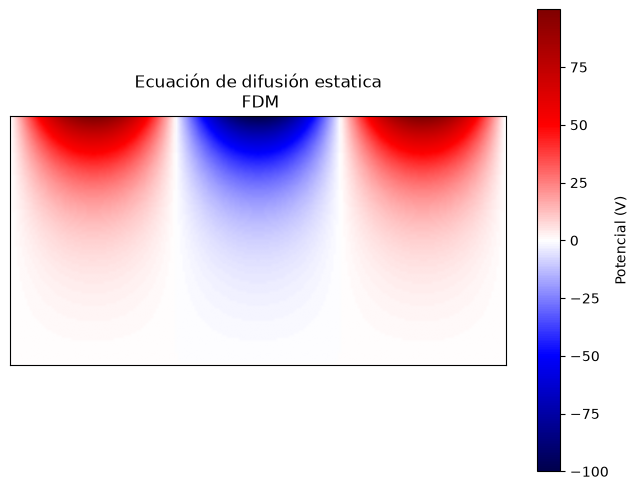

In [144]:
#grafica solucion estatica
plt.figure(figsize=(8,6))
plt.imshow(t_sta, origin='lower', cmap='seismic', extent=[0, nx, 0, ny], interpolation='bilinear')
plt.title(f'Ecuación de difusión estatica\n FDM')
plt.xticks([])
plt.yticks([])
plt.colorbar(label='Potencial (V)')
plt.show()

# Solucion analitica #

Para la solucion analitica en el caso estacionario  partimos de la ecuacion de difusion tomando la parte temporal como cero:

$$\frac{\partial^2T(x,y)}{\partial x^2} +  \frac{\partial^2 T(x,y)}{\partial y^2} = 0  $$

procedemos con la solucion mediante separacion de varibles, y aplicando las respectivas condiciones de frontera se llega  a una solucion de la forma:

$$ T(x,y) = 100\frac {\sinh(\frac{3\pi y}{a})}{\sinh(\frac{3\pi b}{a})} \sin(\frac{3\pi x}{a})  $$


In [145]:
#Solucion analitica 
X , Y = np.meshgrid(x,y)
T_analy = Diffusionanalytical (X, Y, a,b)

#Calculo de diferencias entre las solcuiones
error = np.max(np.abs(T_analy - t_sta)) * 100

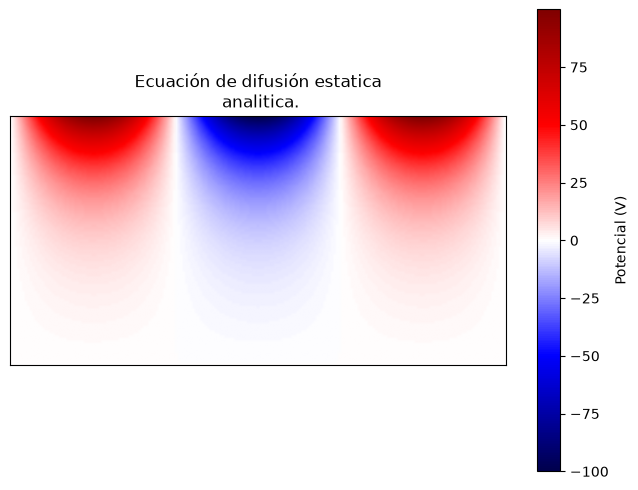

In [146]:
plt.figure(figsize=(8,6))
plt.imshow(T_analy, origin='lower', cmap='seismic', extent=[0, nx, 0, ny], interpolation='bilinear')
plt.title(f'Ecuación de difusión estatica\n analitica.')
plt.xticks([])
plt.yticks([])
plt.colorbar(label='Potencial (V)')
plt.show()

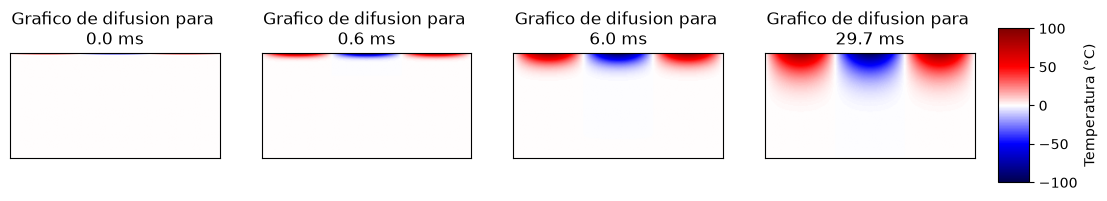

In [ ]:
#Pasos totales de ejecucion temporal
nsteps = 1000
#Graficos donde paran las simulaciones 
graf = {0, 20 , 200 , 1000 - 1}


fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 10))
pos = 0
u0=u00.copy()
for m in range(nsteps):
    u = Diffusion2D_sli(u0, dt, dx, dy, D)
    u0 = u.copy()
    
    if m in graf:
        im = axs[pos].imshow(u, origin='lower', cmap='seismic', extent=[0, nx, 0, ny], interpolation='bilinear',vmin=-100,vmax=100)
        axs[pos].set_title(f'Grafico de difusion para \n{m * dt * 1000 :.1f} ms')
        axs[pos].set_xticks([])
        axs[pos].set_yticks([])
        pos += 1

cbar = fig.colorbar(im, ax=axs, shrink=0.2, aspect=5, pad=0.02)
cbar.set_label('Temperatura (°C)')
plt.show()